In [ ]:
import numpy as np
import math


In [ ]:
def quaternion_inverse(q):
    """计算四元数的逆/共轭（假设 q 是单位四元数）"""
    w, x, y, z = q
    return np.array([w, -x, -y, -z])

def quaternion_multiply(q1, q2):
    """计算两个四元数的乘积 (Hamilton 乘积)"""
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2
    w = w1*w2 - x1*x2 - y1*y2 - z1*z2
    x = w1*x2 + x1*w2 + y1*z2 - z1*y2
    y = w1*y2 - x1*z2 + y1*w2 + z1*x2
    z = w1*z2 + x1*y2 - y1*x2 + z1*w2
    return np.array([w, x, y, z])

def rotate_vector_by_quaternion(q, v):
    """使用四元数 q 旋转向量 v (v_rot = q * v * q^-1)"""
    # 将 3D 向量转换为纯虚四元数 [0, vx, vy, vz]
    v_quat = np.array([0.0, v[0], v[1], v[2]])
    q_conj = quaternion_inverse(q)
    
    # 实施旋转: q * v * q*
    temp = quaternion_multiply(q_conj, v_quat)
    res_quat = quaternion_multiply(temp, q)
    
    # 返回前三个分量作为旋转后的 3D 向量
    return res_quat[1:]

In [ ]:
def quat_from_axis_angle(axis, deg):
    axis = np.asarray(axis, dtype=float)
    axis = axis / np.linalg.norm(axis)

    theta = math.radians(deg)

    w = math.cos(theta / 2)
    xyz = axis * math.sin(theta / 2)

    return np.array([w, *xyz])

In [ ]:
quat_from_axis_angle([1,0,0], 0.)

In [ ]:
def quat_to_matrix(q):
    w, x, y, z = q
    return np.array([
        [1 - 2*(y*y + z*z), 2*(x*y - w*z), 2*(x*z + w*y)],
        [2*(x*y + w*z), 1 - 2*(x*x + z*z), 2*(y*z - w*x)],
        [2*(x*z - w*y), 2*(y*z + w*x), 1 - 2*(x*x + y*y)]
    ])

In [ ]:
g_world = np.array([0.0, 0.0, -1.0])

In [ ]:
cases = {
    "upright": ([1,0,0], 0),
    "yaw +90": ([0,0,1], 90),
    "pitch +90": ([0,1,0], 30),
    "roll +90": ([1,0,0], 30),
}

In [ ]:
for name, (axis, deg) in cases.items():
    q = quat_from_axis_angle(axis, deg)
    R_WB = quat_to_matrix(q)

    g_body_R_WB = R_WB.T @ g_world
    g_body_q = rotate_vector_by_quaternion(q, g_world)

    print(f"\n=== {name} ===")
    print("quaternion:")
    print(np.round(q, 4))

    print("R_WB:")
    print(np.round(R_WB, 4))

    print("projected gravity:")
    print(np.round(g_body_R_WB, 4))
    print(np.round(g_body_q, 4))

In [ ]:
import numpy as np
import mujoco

In [ ]:
# ============================================================
# 1. Build a simple 2-link robot
#
# joint1 and joint2 are both revolute joints around local z-axis.
# The end-effector site "ee" is attached to the tip of link2.
# ============================================================

XML = r"""
<mujoco model="jacobian_demo">
    <compiler angle="radian"/>

    <worldbody>

        <body name="link1" pos="0 0 0">

            <!-- Revolute joint 1 -->
            <joint
                name="joint1"
                type="hinge"
                pos="0 0 0"
                axis="0 0 1"
            />

            <geom
                type="capsule"
                fromto="0 0 0  1 0 0"
                size="0.04"
                rgba="0.3 0.6 0.9 1"
            />

            <!-- link2 starts at the end of link1 -->
            <body name="link2" pos="1 0 0">

                <!-- Revolute joint 2 -->
                <joint
                    name="joint2"
                    type="hinge"
                    pos="0 0 0"
                    axis="0 0 1"
                />

                <geom
                    type="capsule"
                    fromto="0 0 0  0.8 0 0"
                    size="0.04"
                    rgba="0.9 0.5 0.3 1"
                />

                <!-- End-effector -->
                <site
                    name="ee"
                    pos="0.8 0 0"
                    size="0.06"
                    rgba="0 1 0 1"
                />

            </body>
        </body>

    </worldbody>
</mujoco>
"""


model = mujoco.MjModel.from_xml_string(XML)
data = mujoco.MjData(model)

In [ ]:
# ============================================================
# 2. Set a non-trivial robot configuration
#
# q = [q1, q2]
# ============================================================

data.qpos[:] = np.array([
    0.4,    # joint1 angle
    -0.7,   # joint2 angle
])

# Compute forward kinematics and all dependent quantities.
mujoco.mj_forward(model, data)

In [ ]:
data.qpos

In [ ]:
# ============================================================
# 3. Find IDs
# ============================================================

site_id = mujoco.mj_name2id(
    model,
    mujoco.mjtObj.mjOBJ_SITE,
    "ee",
)

joint1_id = mujoco.mj_name2id(
    model,
    mujoco.mjtObj.mjOBJ_JOINT,
    "joint1",
)

joint2_id = mujoco.mj_name2id(
    model,
    mujoco.mjtObj.mjOBJ_JOINT,
    "joint2",
)

In [ ]:
print(site_id, joint1_id, joint2_id)

In [ ]:
# ============================================================
# 4. Compute Jacobian using MuJoCo
#
# jacp:
#     translational Jacobian
#     shape = (3, nv)
#
# jacr:
#     rotational Jacobian
#     shape = (3, nv)
# ============================================================

jacp = np.zeros((3, model.nv))
jacr = np.zeros((3, model.nv))

mujoco.mj_jacSite(
    model,
    data,
    jacp,
    jacr,
    site_id,
)

print("=" * 70)
print("MuJoCo translational Jacobian Jp")
print(jacp)

print("\nMuJoCo rotational Jacobian Jr")
print(jacr)

In [ ]:
# ============================================================
# 5. Inspect actual geometric quantities
#
# p_F^W:
#     end-effector position in world coordinates
#
# p_i^W:
#     joint anchor position in world coordinates
#
# a_i^W:
#     joint axis in world coordinates
# ============================================================

p_foot_W = data.site_xpos[site_id].copy()

print("\n" + "=" * 70)
print("End-effector position p_F^W:")
print(p_foot_W)

p_joint1_pos = data.xanchor[joint1_id]

print("\n" + "=" * 70)
print("joint1 anchor position p_1^W:")
print(p_joint1_pos)

p_joint2_pos = data.xanchor[joint2_id]

print("\n" + "=" * 70)
print("joint2 anchor position p_2^W:")
print(p_joint2_pos)

p_joint1_axis = data.xaxis[joint1_id]

print("\n" + "=" * 70)
print("joint1 axis a_1^W:")
print(p_joint1_axis)

p_joint2_axis = data.xaxis[joint2_id]

print("\n" + "=" * 70)
print("joint2 axis a_2^W:")
print(p_joint2_axis)

In [ ]:
# ============================================================
# 6. Reconstruct the Jacobian manually using geometry
#
# For a revolute joint:
#
#   Jp[:, i] = a_i^W x (p_F^W - p_i^W)
#
#   Jr[:, i] = a_i^W
#
# ============================================================

jacp_manual = np.zeros((3, model.nv))
jacr_manual = np.zeros((3, model.nv))

for joint_id in [joint1_id, joint2_id]:

    # Each hinge joint has exactly one DoF.
    dof_id = model.jnt_dofadr[joint_id]

    # Joint position in world coordinates.
    p_i_W = data.xanchor[joint_id].copy()

    # Joint rotation axis in world coordinates.
    a_i_W = data.xaxis[joint_id].copy()

    # Translational Jacobian column.
    jacp_manual[:, dof_id] = np.cross(
        a_i_W,
        p_foot_W - p_i_W,
    )

    # Rotational Jacobian column.
    jacr_manual[:, dof_id] = a_i_W

    joint_name = mujoco.mj_id2name(
        model,
        mujoco.mjtObj.mjOBJ_JOINT,
        joint_id,
    )

    print("\n" + "-" * 70)
    print(f"{joint_name}")
    print("joint position p_i^W =", p_i_W)
    print("joint axis     a_i^W =", a_i_W)

    print(
        "a_i^W x (p_F^W - p_i^W) =",
        jacp_manual[:, dof_id],
    )


print("\n" + "=" * 70)
print("Manual geometric Jp")
print(jacp_manual)

print("\nManual geometric Jr")
print(jacr_manual)

In [ ]:
# ============================================================
# 7. Compare MuJoCo Jacobian and geometric Jacobian
# ============================================================

print("\n" + "=" * 70)

print(
    "max |Jp_mujoco - Jp_manual| =",
    np.max(np.abs(jacp - jacp_manual)),
)

print(
    "max |Jr_mujoco - Jr_manual| =",
    np.max(np.abs(jacr - jacr_manual)),
)

In [ ]:
# ============================================================
# 8. Choose a generalized velocity
#
# qdot = [qdot1, qdot2]
# ============================================================

v = np.array([
    0.8,    # joint1: rad/s
    -0.4,   # joint2: rad/s
])


# ============================================================
# 9. Jacobian predicts Cartesian velocity
#
# v_F^W     = Jp v
# omega_F^W = Jr v
# ============================================================

v_foot_pred = jacp @ v
omega_foot_pred = jacr @ v

print("\n" + "=" * 70)
print("generalized velocity v:")
print(v)

print("\nPredicted foot linear velocity Jp @ v:")
print(v_foot_pred)

print("\nPredicted foot angular velocity Jr @ v:")
print(omega_foot_pred)

In [ ]:
# ============================================================
# 10. Verify the linear velocity using finite differences
#
# We make a VERY small motion:
#
#     q(t + dt) = integrate(q(t), v, dt)
#
# and compare:
#
#     (p(t + dt) - p(t)) / dt
#
# against:
#
#     Jp @ v
#
# mj_integratePos is used instead of qpos += v * dt.
# This is important for models containing quaternion joints.
# ============================================================

dt = 1e-7

qpos0 = data.qpos.copy()
p0 = data.site_xpos[site_id].copy()

R0 = data.site_xmat[site_id].reshape(3, 3).copy()


# Create a second data object for the perturbed configuration.
data_next = mujoco.MjData(model)
data_next.qpos[:] = qpos0


# Correctly integrate generalized position.
mujoco.mj_integratePos(
    model,
    data_next.qpos,
    v,
    dt,
)

mujoco.mj_forward(model, data_next)


p1 = data_next.site_xpos[site_id].copy()
R1 = data_next.site_xmat[site_id].reshape(3, 3).copy()


# Finite-difference linear velocity.
v_foot_fd = (p1 - p0) / dt

print("\n" + "=" * 70)
print("Finite-difference linear velocity:")
print(v_foot_fd)

print("\nJacobian-predicted linear velocity:")
print(v_foot_pred)

print(
    "\nlinear velocity error =",
    np.linalg.norm(v_foot_fd - v_foot_pred),
)

In [ ]:
# ============================================================
# 11. Verify angular velocity using rotation matrices
#
# For a small world-frame rotation:
#
#     R1 R0^T ~= I + [omega^W]_x dt
#
# Therefore:
#
#     [omega^W]_x
#       ~= (R_delta - R_delta^T) / (2 dt)
#
# ============================================================

R_delta = R1 @ R0.T

omega_skew = (
    R_delta - R_delta.T
) / (2.0 * dt)

# vee operator:
#
# [  0  -wz   wy ]
# [ wz    0  -wx ]
# [-wy   wx    0 ]
#
omega_foot_fd = np.array([
    omega_skew[2, 1],
    omega_skew[0, 2],
    omega_skew[1, 0],
])

print("\n" + "=" * 70)
print("Finite-difference angular velocity:")
print(omega_foot_fd)

print("\nJacobian-predicted angular velocity:")
print(omega_foot_pred)

print(
    "\nangular velocity error =",
    np.linalg.norm(
        omega_foot_fd - omega_foot_pred
    ),
)

In [ ]:
# ============================================================
# 12. Automatic checks
# ============================================================

assert np.allclose(
    jacp,
    jacp_manual,
    atol=1e-10,
)

assert np.allclose(
    jacr,
    jacr_manual,
    atol=1e-10,
)

assert np.allclose(
    v_foot_pred,
    v_foot_fd,
    atol=1e-6,
)

assert np.allclose(
    omega_foot_pred,
    omega_foot_fd,
    atol=1e-6,
)

print("\n" + "=" * 70)
print("All Jacobian checks passed.")

## Inverse velocity kinematics

In [ ]:
import mujoco


XML = r"""
<mujoco model="jacobian_demo">
    <compiler angle="radian"/>

    <worldbody>

        <body name="link1" pos="0 0 0">

            <!-- Revolute joint 1 -->
            <joint
                name="joint1"
                type="hinge"
                pos="0 0 0"
                axis="0 0 1"
            />

            <geom
                type="capsule"
                fromto="0 0 0  1 0 0"
                size="0.04"
                rgba="0.3 0.6 0.9 1"
            />

            <!-- link2 starts at the end of link1 -->
            <body name="link2" pos="1 0 0">

                <!-- Revolute joint 2 -->
                <joint
                    name="joint2"
                    type="hinge"
                    pos="0 0 0"
                    axis="0 0 1"
                />

                <geom
                    type="capsule"
                    fromto="0 0 0  0.8 0 0"
                    size="0.04"
                    rgba="0.9 0.5 0.3 1"
                />

                <!-- End-effector -->
                <site
                    name="ee"
                    pos="0.8 0 0"
                    size="0.06"
                    rgba="0 1 0 1"
                />

            </body>
        </body>

    </worldbody>
</mujoco>
"""

In [ ]:
model = mujoco.MjModel.from_xml_string(XML)
data = mujoco.MjData(model)

In [ ]:
data.qpos[:] = [0.5, -0.7]

In [ ]:
mujoco.mj_forward(model, data)

In [ ]:
site_id = mujoco.mj_name2id(
    model,
    mujoco.mjtObj.mjOBJ_SITE,
    "ee",
)
# site_id = model.site["ee"].id

In [ ]:
# world coordinates
p0 = data.site_xpos[site_id].copy() # site_xpos is mutable if calling mj_forward.
p0

In [ ]:
import numpy as np

jacp = np.zeros((3, model.nv))
jacr = np.zeros((3, model.nv))

mujoco.mj_jacSite(
    model,
    data,
    jacp,
    jacr,
    site_id
)
print(f"Jacobian position: {jacp}")
print(f"Jacobian rotation: {jacr}")

In [ ]:
jac = jacp[:2, :]

In [ ]:
v_des = np.array([0.1, 0.05])

In [ ]:
qdot = np.linalg.pinv(jac) @ v_des
qdot

In [ ]:
v_pred = jac @ qdot
v_pred

In [ ]:
dt = 1e-4
mujoco.mj_integratePos(model, data.qpos, qdot, dt)

In [ ]:
mujoco.mj_forward(model, data)

In [ ]:
p1 = data.site_xpos[site_id].copy()
p1

In [ ]:
p0

In [ ]:
v_actual = (p1[:2] - p0[:2]) / dt
print(f"v_desired: {v_des}")
print(f"v_real: {v_actual}")

In [ ]:
v_des = np.array([0., 0.05])
for step in range(50):
    p_old = data.site_xpos[site_id].copy()
    mujoco.mj_forward(model, data)
    p_new = data.site_xpos[site_id].copy()
    v_actual = (p_new[:2] - p_old[:2]) / dt
    print(f"new site xpos: {p_new}")
    print(f"mse between v_des & v_actual: {np.mean((v_actual-v_des)**2)}")
    

    # compute Jacobian
    jacp = np.zeros((3, model.nv))
    jacr = np.zeros((3, model.nv))
    mujoco.mj_jacSite(
        model, data, jacp, jacr, site_id,
    )
    jac = jacp[:2, :]

    # compute qdot
    qdot = np.linalg.pinv(jac) @ v_des

    # integrate qpos
    mujoco.mj_integratePos(model, data.qpos, qdot, dt)
    print(f"qpos: {data.qpos}")


In [ ]:
test_q2 = [1., 0.5, 0.1, 0.01, 0.001]
lambda_ = 0.001

for _q2 in test_q2:
    data.qpos[:] = [0.5, _q2]
    mujoco.mj_forward(model, data)

    jacp = np.zeros((3, model.nv))
    jacr = np.zeros((3, model.nv))

    mujoco.mj_jacSite(
        model,
        data,
        jacp,
        jacr,
        site_id,
    )

    j = jacp[:2]

    singular_values = np.linalg.svd(j, compute_uv=False)

    qdot = np.linalg.pinv(j) @ v_des

    qdot_dls = j.T @ np.linalg.solve(j @ j.T + lambda_**2 * np.eye(j.shape[0]), v_des)

    print(f"singluar values:\n {singular_values}")
    print(f"qdot norms:\n {np.linalg.norm(qdot)}")
    print(f"qdot_dls norms:\n {np.linalg.norm(qdot_dls)}")

In [ ]:
import numpy as np
import mujoco

In [ ]:
def get_mass_matrix(model, data):
    nv = model.nv
    M = np.zeros((nv, nv))

    for j in range(nv):
        e = np.zeros(nv)
        e[j] = 1.0
        Me = np.zeros(nv)
        mujoco.mj_mulM(
            model, data, Me, e,
        )

        M[:, j] = Me

    return M

In [ ]:
from mjlab_microduck.robot.microduck_constants import MICRODUCK_WALK_XML

In [ ]:
model = mujoco.MjModel.from_xml_path(str(MICRODUCK_WALK_XML))
data = mujoco.MjData(model)

In [ ]:
mujoco.mj_forward(model, data)

In [ ]:
print("nq = ", model.nq)
print("nv = ", model.nv)
print("nu = ", model.nu)

In [ ]:
knee_joint_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, "left_knee")
knee_dof = model.jnt_dofadr[knee_joint_id]
print("left_knee dof=", knee_dof)

In [ ]:
data.qfrc_applied[:] = 0.0
data.qfrc_applied[knee_dof] = 0.03

In [ ]:
hip_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, "left_hip_pitch")
hip_dof = model.jnt_dofadr[hip_id]

data.qvel[:] = 0.0
data.qvel[hip_dof] = 1.0
data.qvel[knee_dof] = -1.5

mujoco.mj_forward(model, data)

In [ ]:
M = get_mass_matrix(model, data)

In [ ]:
rhs = (data.qfrc_passive + data.qfrc_actuator + data.qfrc_applied + data.qfrc_constraint - data.qfrc_bias)

In [ ]:
qacc_manual = np.linalg.solve(M, rhs)

In [ ]:
qacc_mujoco = data.qacc.copy()

In [ ]:
error = qacc_manual - qacc_mujoco

print("max abs error:", np.max(np.abs(error)))
print("L2 error:", np.linalg.norm(error))

In [ ]:
data.qfrc_constraint

In [ ]:
mujoco.mj_forward(model, data)

qacc_forward = data.qacc.copy()
applied_force = data.qfrc_applied.copy()

In [ ]:
data.qacc[:] = qacc_forward

mujoco.mj_inverse(model, data)
print(data.qfrc_inverse)

In [ ]:
print(applied_force)

In [ ]:
data.qfrc_applied

In [ ]:
data

In [ ]:
data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.genfromtxt("bam_amp_020.csv", delimiter=',', names=True)
roi = 1600
duration = 400

t = data["time"][roi:roi+duration]

fig, axes = plt.subplots(6, 1, sharex=True, figsize=(9, 14))
fig.suptitle("BAM 0-delay Step Response delta-q = 0.2")
axes[0].plot(t, data['applied_target'][roi:roi+duration], label="applied target")
axes[0].plot(t, data['command_target'][roi:roi+duration], label="command target")
axes[0].plot(t, data['q'][roi:roi+duration], label="actual q")
axes[0].plot(t, data['base_z_pos'][roi:roi+duration], label="actual z")
axes[0].set_ylabel("position [rad]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, data['qvel'][roi:roi+duration], label='qvel')
axes[1].plot(t, data['base_z_velocity'][roi:roi+duration], label='z vel')
axes[1].set_ylabel("velocity [rad/s]")
axes[1].grid(True)
axes[1].legend()

axes[2].plot(t, data['base_omega_x'][roi:roi+duration], label='w_x vel')
axes[2].plot(t, data['base_omega_y'][roi:roi+duration], label='w_y vel')
axes[2].plot(t, data['base_omega_z'][roi:roi+duration], label='w_z vel')
axes[2].set_ylabel("w velocity [rad/s]")
axes[2].grid(True)
axes[2].legend()

axes[3].plot(t, data["torque"][roi:roi+duration], label="motor torque")
axes[3].plot(t, data["constraint_torque"][roi:roi+duration], label="constraint")
axes[3].set_ylabel("torque [N m]")
axes[3].grid(True)
axes[3].legend()

axes[4].plot(t, data['applied_target'][roi:roi+duration] - data['q'][roi:roi+duration], label="applied error")
axes[4].plot(t, data['command_target'][roi:roi+duration] - data['q'][roi:roi+duration], label="command error")
axes[4].set_ylabel("position[rad]")
axes[4].legend()
axes[4].grid(True)

axes[5].plot(t, data['num_constraint'][roi:roi+duration])
axes[5].set_ylabel("num constaints")
axes[5].grid(True)

axes[5].set_xlabel("time [s]")
plt.tight_layout()
plt.show()

In [ ]:
data = np.genfromtxt("bam_amp_020_delay4.csv", delimiter=',', names=True)
roi = 1600
duration = 400

t = data["time"][roi:roi+duration]

fig, axes = plt.subplots(6, 1, sharex=True, figsize=(9, 14))
fig.suptitle("BAM 4-delay Step Response delta-q = 0.2")
axes[0].plot(t, data['applied_target'][roi:roi+duration], label="applied target")
axes[0].plot(t, data['command_target'][roi:roi+duration], label="command target")
axes[0].plot(t, data['q'][roi:roi+duration], label="actual q")
axes[0].plot(t, data['base_z_pos'][roi:roi+duration], label="actual z")
axes[0].set_ylabel("position [rad]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, data['qvel'][roi:roi+duration], label='qvel')
axes[1].plot(t, data['base_z_velocity'][roi:roi+duration], label='z vel')
axes[1].set_ylabel("velocity [rad/s]")
axes[1].grid(True)
axes[1].legend()

axes[2].plot(t, data['base_omega_x'][roi:roi+duration], label='w_x vel')
axes[2].plot(t, data['base_omega_y'][roi:roi+duration], label='w_y vel')
axes[2].plot(t, data['base_omega_z'][roi:roi+duration], label='w_z vel')
axes[2].set_ylabel("w velocity [rad/s]")
axes[2].grid(True)
axes[2].legend()

axes[3].plot(t, data["torque"][roi:roi+duration], label="motor torque")
axes[3].plot(t, data["constraint_torque"][roi:roi+duration], label="constraint")
axes[3].set_ylabel("torque [N m]")
axes[3].grid(True)
axes[3].legend()

axes[4].plot(t, data['applied_target'][roi:roi+duration] - data['q'][roi:roi+duration], label="applied error")
axes[4].plot(t, data['command_target'][roi:roi+duration] - data['q'][roi:roi+duration], label="command error")
axes[4].set_ylabel("position[rad]")
axes[4].legend()
axes[4].grid(True)

axes[5].plot(t, data['num_constraint'][roi:roi+duration])
axes[5].set_ylabel("num constaints")
axes[5].grid(True)

axes[5].set_xlabel("time [s]")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

roi = 1600
duration = 400

experiments = {
    0.00: "bam_amp_000.csv",
    0.02: "bam_amp_002.csv",
    0.05: "bam_amp_005.csv",
    0.10: "bam_amp_010.csv",
    0.20: "bam_amp_020.csv",
}

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(9, 10))

for delta_q, path in experiments.items():
    data = np.genfromtxt(path, delimiter=",", names=True)

    t = data["time"][roi:roi+duration]

    # actual displacement relative to
    # the pre-step initial position
    q0 = data["q"][0]

    dq_position = (data["q"] - q0)

    axes[0].plot(t, dq_position[roi:roi+duration], label=f"Δq={delta_q:.2f}")
    axes[1].plot(t, data["qvel"][roi:roi+duration], label=f"Δq={delta_q:.2f}")
    axes[2].plot(t, data["torque"][roi:roi+duration], label=f"Δq={delta_q:.2f}")


axes[0].set_ylabel("Position change [rad]")
axes[1].set_ylabel("Velocity [rad/s]")
axes[2].set_ylabel("Motor torque [N m]")
axes[2].set_xlabel("Time [s]")

for ax in axes:
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
data['q'].shape

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.genfromtxt("pd_amp_020_kp1.csv", delimiter=',', names=True)
roi = 1600
duration = 400

t = data["time"][roi:roi+duration]

fig, axes = plt.subplots(6, 1, sharex=True, figsize=(9, 14))
fig.suptitle("PD 0-delay Step Response delta-q = 0.2")
axes[0].plot(t, data['applied_target'][roi:roi+duration], label="applied target")
axes[0].plot(t, data['command_target'][roi:roi+duration], label="command target")
axes[0].plot(t, data['q'][roi:roi+duration], label="actual q")
axes[0].plot(t, data['base_z_pos'][roi:roi+duration], label="actual z")
axes[0].set_ylabel("position [rad]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, data['qvel'][roi:roi+duration], label='qvel')
axes[1].plot(t, data['base_z_velocity'][roi:roi+duration], label='z vel')
axes[1].set_ylabel("velocity [rad/s]")
axes[1].grid(True)
axes[1].legend()

axes[2].plot(t, data['base_omega_x'][roi:roi+duration], label='w_x vel')
axes[2].plot(t, data['base_omega_y'][roi:roi+duration], label='w_y vel')
axes[2].plot(t, data['base_omega_z'][roi:roi+duration], label='w_z vel')
axes[2].set_ylabel("w velocity [rad/s]")
axes[2].grid(True)
axes[2].legend()

axes[3].plot(t, data["torque"][roi:roi+duration], label="motor torque")
axes[3].plot(t, data["tau_pd_raw"][roi:roi+duration], label="tau pd raw")
axes[3].plot(t, data["constraint_torque"][roi:roi+duration], label="constraint")
axes[3].set_ylabel("torque [N m]")
axes[3].grid(True)
axes[3].legend()

axes[4].plot(t, data['applied_target'][roi:roi+duration] - data['q'][roi:roi+duration], label="applied error")
axes[4].plot(t, data['command_target'][roi:roi+duration] - data['q'][roi:roi+duration], label="command error")
axes[4].set_ylabel("position[rad]")
axes[4].legend()
axes[4].grid(True)

axes[5].plot(t, data['num_constraint'][roi:roi+duration])
axes[5].set_ylabel("num constaints")
axes[5].grid(True)
axes[5].set_xlabel("time [s]")

fig1, axes1 = plt.subplots(1, 1, sharex=True, figsize=(6, 6))
fig1.suptitle("tau vs error")

axes1.plot(data['applied_target'][roi+1:roi+duration] - data['q'][roi+1:roi+duration], data['tau_pd_raw'][roi+1:roi+duration])
axes1.set_xlabel("error")
axes1.set_ylabel("tau pd raw")
axes1.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
data['applied_target'][roi:roi+duration].shape

In [ ]:
data['tau_pd_raw'][roi:roi+duration].s

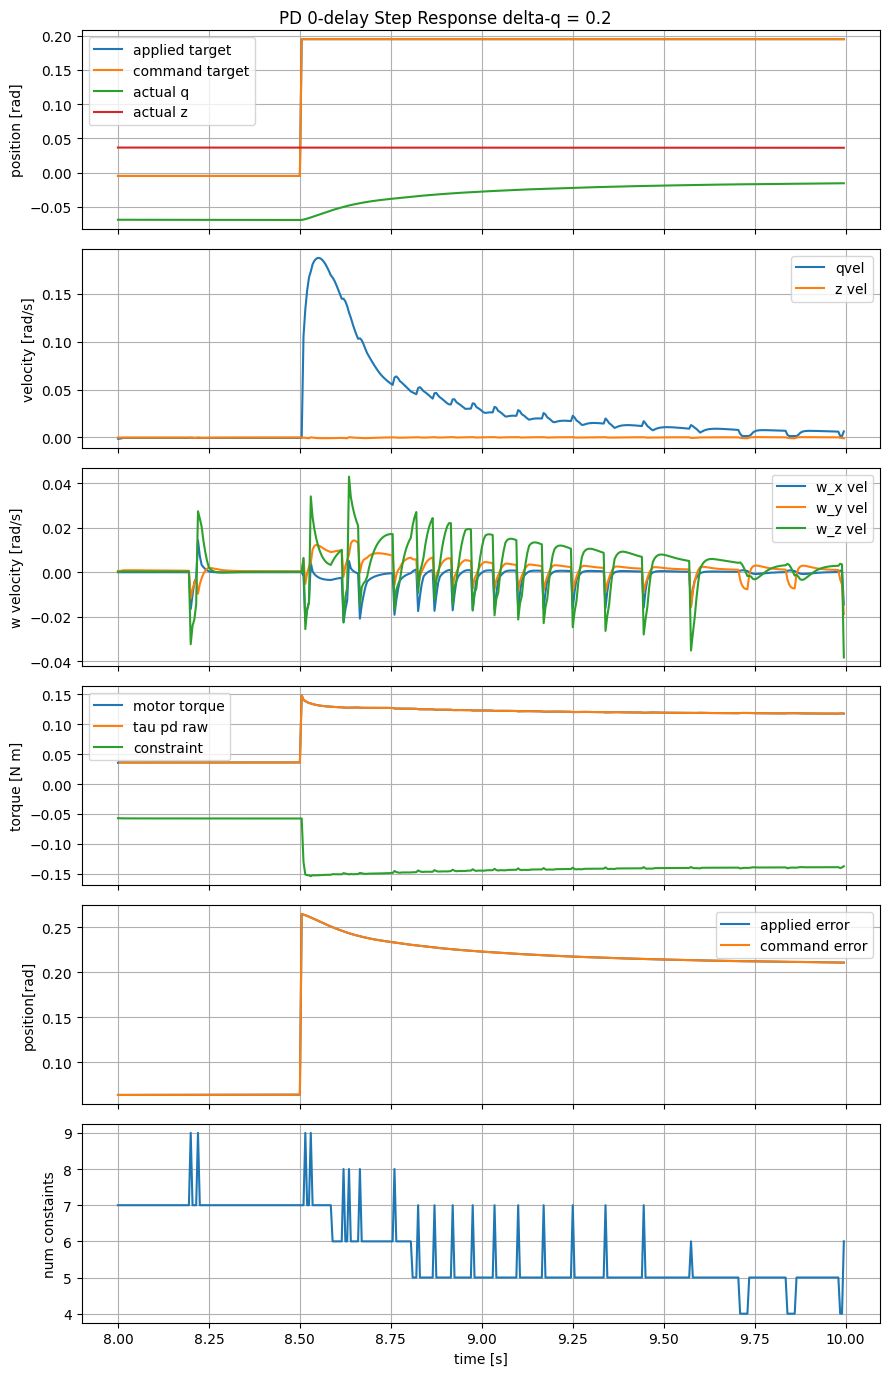

In [5]:
import numpy as np
import matplotlib.pyplot as plt

data = np.genfromtxt("pd_amp_020.csv", delimiter=',', names=True)
roi = 1600
duration = 400

t = data["time"][roi:roi+duration]

fig, axes = plt.subplots(6, 1, sharex=True, figsize=(9, 14))
fig.suptitle("PD 0-delay Step Response delta-q = 0.2")
axes[0].plot(t, data['applied_target'][roi:roi+duration], label="applied target")
axes[0].plot(t, data['command_target'][roi:roi+duration], label="command target")
axes[0].plot(t, data['q'][roi:roi+duration], label="actual q")
axes[0].plot(t, data['base_z_pos'][roi:roi+duration], label="actual z")
axes[0].set_ylabel("position [rad]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, data['qvel'][roi:roi+duration], label='qvel')
axes[1].plot(t, data['base_z_velocity'][roi:roi+duration], label='z vel')
axes[1].set_ylabel("velocity [rad/s]")
axes[1].grid(True)
axes[1].legend()

axes[2].plot(t, data['base_omega_x'][roi:roi+duration], label='w_x vel')
axes[2].plot(t, data['base_omega_y'][roi:roi+duration], label='w_y vel')
axes[2].plot(t, data['base_omega_z'][roi:roi+duration], label='w_z vel')
axes[2].set_ylabel("w velocity [rad/s]")
axes[2].grid(True)
axes[2].legend()

axes[3].plot(t, data["torque"][roi:roi+duration], label="motor torque")
axes[3].plot(t, data["tau_pd_raw"][roi:roi+duration], label="tau pd raw")
axes[3].plot(t, data["constraint_torque"][roi:roi+duration], label="constraint")
axes[3].set_ylabel("torque [N m]")
axes[3].grid(True)
axes[3].legend()

axes[4].plot(t, data['applied_target'][roi:roi+duration] - data['q'][roi:roi+duration], label="applied error")
axes[4].plot(t, data['command_target'][roi:roi+duration] - data['q'][roi:roi+duration], label="command error")
axes[4].set_ylabel("position[rad]")
axes[4].legend()
axes[4].grid(True)

axes[5].plot(t, data['num_constraint'][roi:roi+duration])
axes[5].set_ylabel("num constaints")
axes[5].grid(True)

axes[5].set_xlabel("time [s]")
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd

data = pd.read_csv("mjlab_step_response.csv")
data = data.to_numpy()

In [4]:
data

array([[0.0, 0.02, -0.0049000000581145, ..., 0.0, 0.0,
        "tensor(0., device='cuda:0')"],
       [0.02, 0.04, -0.0049000000581145, ..., 1.178119659423828,
        0.2301631285095229, "tensor(4., device='cuda:0')"],
       [0.04, 0.06, -0.0049000000581145, ..., 0.8533741235733032,
        0.2375027902000477, "tensor(4., device='cuda:0')"],
       ...,
       [9.94, 9.96, 0.1951000029221177, ..., 0.0717231333255767,
        0.0501193428260021, "tensor(4., device='cuda:0')"],
       [9.96, 9.98, 0.1951000029221177, ..., 0.0319656282663345,
        0.0262929370520825, "tensor(4., device='cuda:0')"],
       [9.98, 10.0, 0.1951000029221177, ..., 0.1121188476681709,
        0.0791670535145512, "tensor(4., device='cuda:0')"]],
      shape=(500, 18), dtype=object)

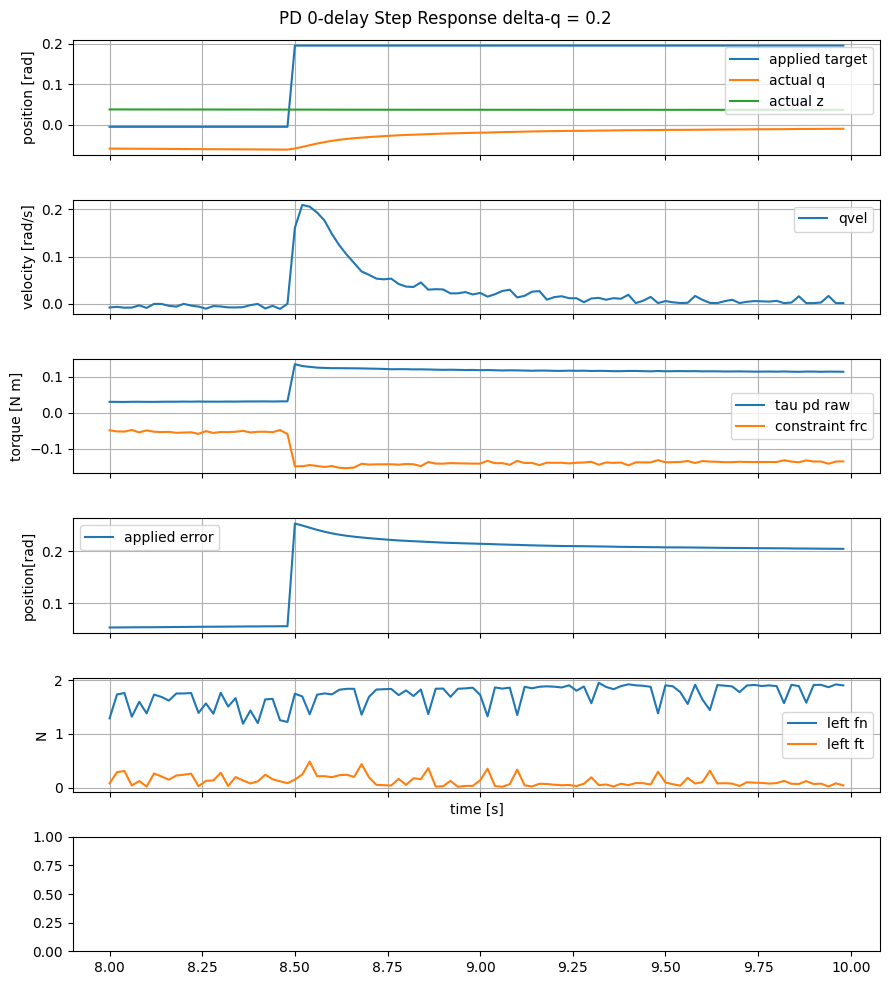

In [6]:
import numpy as np
import matplotlib.pyplot as plt

data = np.genfromtxt("mjlab_step_response.csv", delimiter=',', names=True)
roi = 400
duration = 500

t = data["time"][roi:roi+duration]

fig, axes = plt.subplots(6, 1, sharex=True, figsize=(9, 10))
fig.suptitle("PD 0-delay Step Response delta-q = 0.2")
axes[0].plot(t, data['target'][roi:roi+duration], label="applied target")
axes[0].plot(t, data['q'][roi:roi+duration], label="actual q")
axes[0].plot(t, data['base_z'][roi:roi+duration], label="actual z")
axes[0].set_ylabel("position [rad]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, data['qvel'][roi:roi+duration], label='qvel')
axes[1].set_ylabel("velocity [rad/s]")
axes[1].grid(True)
axes[1].legend()

axes[2].plot(t, data["tau"][roi:roi+duration], label="tau pd raw")
axes[2].plot(t, data["constraint_frc"][roi:roi+duration], label="constraint frc")
axes[2].set_ylabel("torque [N m]")
axes[2].grid(True)
axes[2].legend()

axes[3].plot(t, data["command_error"][roi:roi+duration], label="applied error")
axes[3].set_ylabel("position[rad]")
axes[3].legend()
axes[3].grid(True)

axes[4].plot(t, data["left_fn"][roi:roi+duration], label="left fn")
axes[4].plot(t, data["left_ft"][roi:roi+duration], label="left ft")
axes[4].set_ylabel("N")
axes[4].grid(True)
axes[4].legend()

axes[4].set_xlabel("time [s]")
plt.tight_layout()
plt.show()

In [ ]:
data.shape